In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from arch import arch_model
import statsmodels
import warnings
from statsmodels.tsa.arima.model import ARIMA

In [10]:
data_2008=pd.read_csv(r'..\..\data\raw\data_2008.csv', index_col=0, parse_dates=True)

In [11]:
# 1. 데이터(data)에서의 결측치 확인
final_na_counts = data_2008.isna().sum()

print("--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---")
print(final_na_counts)

print("\n--- 데이터 품질 검증 (시작일 및 샘플) ---")
for col in data_2008.columns:
    first_valid = data_2008[col].first_valid_index()
    last_val = data_2008[col].iloc[-1]
    print(f"{col:15} | 시작일: {first_valid.date()} | 최근값: {last_val:10.2f} | 남은 NaN: {data_2008[col].loc[first_valid:].isna().sum()}")

# 전체 행 수 출력
print(f"\n전체 타임라인 행 수: {len(data_2008)}")

--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---
Brent Crude Oil                   0
Gold Spot                         0
USD/KRW                           0
NASDAQ                            0
KOSDAQ                            0
KOSPI 200 Close                   0
KOSPI 200 Open                    0
KOSPI 200 High                    0
KOSPI 200 Low                     0
KOSPI 200 Volume                  0
VKOSPI_Close                      0
VKOSPI_Change(%)                  0
KODEX 200_Close                 320
KODEX 200_NAV                   320
KODEX 200_Premium               320
KOSPI 200 Return                  1
KOSPI 200 lagged_1_return(%)      2
KOSPI 200 lagged_2_return(%)      3
dtype: int64

--- 데이터 품질 검증 (시작일 및 샘플) ---
Brent Crude Oil | 시작일: 2008-01-02 | 최근값:      72.48 | 남은 NaN: 0
Gold Spot       | 시작일: 2008-01-02 | 최근값:    5230.50 | 남은 NaN: 0
USD/KRW         | 시작일: 2008-01-02 | 최근값:    1432.32 | 남은 NaN: 0
NASDAQ          | 시작일: 2008-01-02 | 최근값:   22668.21 | 남은 NaN: 0
KOSDAQ          |

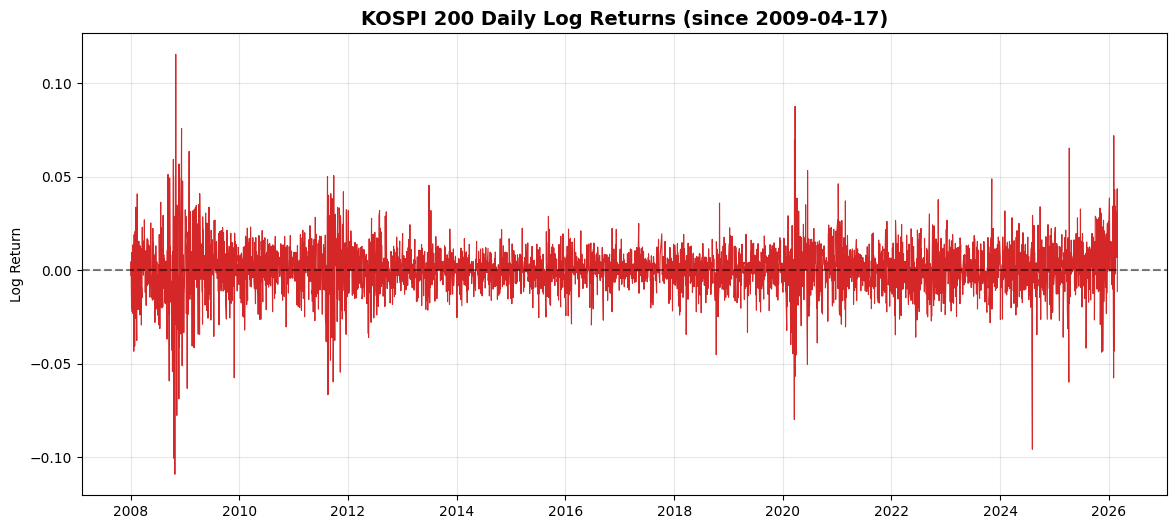

--- KOSPI 200 로그 수익률 기초 통계 ---


count    4428.000000
mean        0.000311
std         0.013063
min        -0.109029
25%        -0.005881
50%         0.000594
75%         0.006923
max         0.115397
Name: KOSPI 200_Log_Return, dtype: float64

In [12]:
# KOSPI 200 로그 수익률 계산: ln(Pt / Pt-1)
# 데이터가 정렬된 상태이므로 shift(1)을 사용하여 계산합니다.
data_2008['KOSPI 200_Log_Return'] = np.log(data_2008['KOSPI 200 Close'] / data_2008['KOSPI 200 Close'].shift(1))

# 시각화
plt.figure(figsize=(14, 6))
plt.plot(data_2008.index, data_2008['KOSPI 200_Log_Return'], color='tab:red', linewidth=0.8)
plt.title('KOSPI 200 Daily Log Returns (since 2009-04-17)', fontsize=14, fontweight='bold')
plt.ylabel('Log Return')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.show()

# 기초 통계량 출력
print("--- KOSPI 200 로그 수익률 기초 통계 ---")
display(data_2008['KOSPI 200_Log_Return'].describe())


In [13]:
#data를 2009-04-17 이후로 자르기
data_2009 = data_2008.loc['2009-04-17':]
data_2009.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4109 entries, 2009-04-17 to 2026-02-27
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Brent Crude Oil               4109 non-null   float64
 1   Gold Spot                     4109 non-null   float64
 2   USD/KRW                       4109 non-null   float64
 3   NASDAQ                        4109 non-null   float64
 4   KOSDAQ                        4109 non-null   float64
 5   KOSPI 200 Close               4109 non-null   float64
 6   KOSPI 200 Open                4109 non-null   float64
 7   KOSPI 200 High                4109 non-null   float64
 8   KOSPI 200 Low                 4109 non-null   float64
 9   KOSPI 200 Volume              4109 non-null   float64
 10  VKOSPI_Close                  4109 non-null   float64
 11  VKOSPI_Change(%)              4109 non-null   float64
 12  KODEX 200_Close               4109 non-null 

In [14]:
#로그 수익률 정상성 검정

from statsmodels.tsa.stattools import adfuller

#로그 수익률 검정을 위해 추출 
full_returns = data_2008['KOSPI 200_Log_Return'].dropna()

# ADF 검정 수행 
#귀무가설 H0: 시계열이 비정상적이다 (Unit Root 존재)
result = adfuller(full_returns)

print('--- KOSPI 200 로그 수익률 ADF 검정 결과 ---')
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4e}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value:.4f}')

if result[1] < 0.05:
    print('\n결과 해석: p-value가 0.05보다 작으므로, 유의수준 5%에서 귀무가설을 기각합니다. 즉, 데이터는 정상성(Stationarity)을 가집니다.')
else:
    print('\n결과 해석: p-value가 0.05보다 크므로, 귀무가설을 기각할 수 없습니다. 데이터가 비정상(Non-stationary)일 가능성이 높습니다.')

--- KOSPI 200 로그 수익률 ADF 검정 결과 ---
ADF Statistic: -67.0027
p-value: 0.0000e+00
Critical Values:
	1%: -3.4318
	5%: -2.8622
	10%: -2.5671

결과 해석: p-value가 0.05보다 작으므로, 유의수준 5%에서 귀무가설을 기각합니다. 즉, 데이터는 정상성(Stationarity)을 가집니다.


In [15]:
# 데이터 분할
# 최종 Risk_Label 데이터가 t+1 구조로 마지막 행이 제거되므로,
# GARCH/GJR 차수 선택용 split도 최종 라벨 데이터 기준 길이에 맞춤
# train:valid:test = 45:35:20

n_for_split = len(data_2009) - 1  # return_t1 생성 시 마지막 row는 t+1이 없어 제거될 예정

train_end_idx = int(n_for_split * 0.45)
valid_end_idx = int(n_for_split * 0.80)

train_returns = data_2009.iloc[:train_end_idx].copy()
valid_returns = data_2009.iloc[train_end_idx:valid_end_idx].copy()
test_returns = data_2009.iloc[valid_end_idx:n_for_split].copy()

print('\n--- 데이터 분할 결과 (45:35:20, 최종 라벨 데이터 기준) ---')
print(f'Train size      : {len(train_returns)}')
print(f'Validation size : {len(valid_returns)}')
print(f'Test size       : {len(test_returns)}')
print(f'Total           : {len(train_returns) + len(valid_returns) + len(test_returns)}')


--- 데이터 분할 결과 (45:35:20, 최종 라벨 데이터 기준) ---
Train size      : 1848
Validation size : 1438
Test size       : 822
Total           : 4108


In [16]:
#train 에서만 최적 ARIMA 차수 탐색
from statsmodels.tsa.arima.model import ARIMA
import itertools

p=range(0, 3) #AR 차수
d=[0]
q=range(0, 3) # MA 차수

pdq=list(itertools.product(p,d,q))
best_aic = float('inf')
best_order = None
best_model = None

#train 에서만 ARIMA 모델 차수 계산
train_returns_ARIMA = train_returns['KOSPI 200_Log_Return'].dropna()    
for order in pdq:
    try:
        model = ARIMA(train_returns_ARIMA, order=order)
        results = model.fit()

        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
        print(f'ARIMA{order} - AIC: {results.aic:.2f}')

    except Exception as e:
        print(f'ARIMA{order} 실패: {e}')
        continue

print(f'\n[최적 결과] Best ARIMA Order (Train only): {best_order} with AIC: {best_aic:.2f}')

print('\n--- Train 기준 최적 ARIMA 모델 상세 요약 ---')
print(best_model.summary())




ARIMA(0, 0, 0) - AIC: -11445.53


c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

ARIMA(0, 0, 1) - AIC: -11443.77
ARIMA(0, 0, 2) - AIC: -11445.22


c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

ARIMA(1, 0, 0) - AIC: -11443.76
ARIMA(1, 0, 1) - AIC: -11438.86


...

ARIMA(1, 0, 2) - AIC: -11443.91


c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\dddhs\a

ARIMA(2, 0, 0) - AIC: -11445.10
ARIMA(2, 0, 1) - AIC: -11443.07


c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(2, 0, 2) - AIC: -11438.80

[최적 결과] Best ARIMA Order (Train only): (0, 0, 0) with AIC: -11445.53

--- Train 기준 최적 ARIMA 모델 상세 요약 ---
                                SARIMAX Results                                 
Dep. Variable:     KOSPI 200_Log_Return   No. Observations:                 1848
Model:                            ARIMA   Log Likelihood                5724.765
Date:                  Wed, 06 May 2026   AIC                         -11445.529
Time:                          13:19:55   BIC                         -11434.485
Sample:                               0   HQIC                        -11441.458
                                 - 1848                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.791      0.429  

### ARIMA(0,0,0)이라 모델링 안해도됨 (예측 코드는 마크다운으로 기록)

# expanding window 방식: 2008 시작부터 전체 구간 1-step 예측
forecast_values = []
forecast_dates = []

full_returns = data_2008['KOSPI 200_Log_Return'].dropna()

for i in range(0, len(full_returns) - 1):
    train_slice = full_returns.iloc[:i+1]  # 첫 관측치부터 현재 시점까지
    
    try:
        model = ARIMA(train_slice, order=best_order)
        results = model.fit()
        
        forecast = results.forecast(steps=1)  # 다음 1시점 예측
        forecast_values.append(forecast.iloc[0])
        forecast_dates.append(full_returns.index[i+1])
    except Exception:
        # 초기 구간에서 모델 학습이 불안정하면 해당 시점은 스킵
        continue

# 예측 시계열 생성
arima_forecast_series = pd.Series(
    forecast_values,
    index=forecast_dates,
    name='ARIMA_forecast'
)

arima_forecast_series.head(), arima_forecast_series.tail(), len(arima_forecast_series)

# ---------------------------------------------------------
# 4. 원본 data에 예측값 결합
#    - 해당 날짜의 ARIMA_forecast는
#      "직전 시점까지의 실제 데이터로 예측한 그 날짜의 값"
# ---------------------------------------------------------
data_2008_arima = data_2008.copy()
data_2008_arima['ARIMA_forecast']=arima_forecast_series
data.head()

### ARCH 자기상관 검정

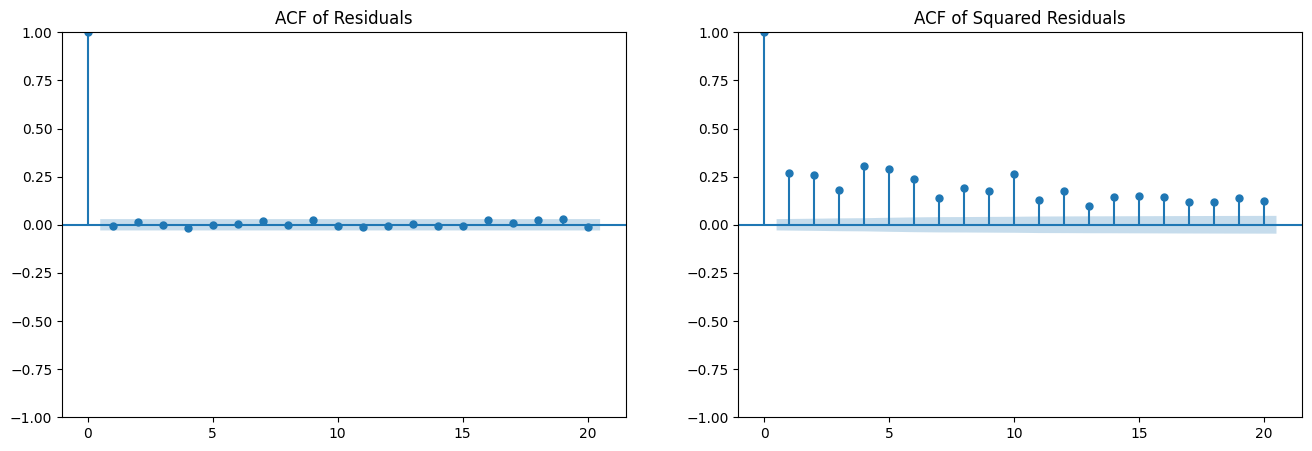

--- ARCH 효과 검정 (Ljung-Box Test on Squared Residuals) ---


,lb_stat,lb_pvalue
10,2515.237077,0.0



결과 해석: p-value(0.0000e+00)가 0.05보다 작으므로 잔차 제곱에 자기상관이 존재합니다.
즉, ARCH 효과가 존재하며 GARCH 모델링을 통한 변동성 분석이 적절합니다.


In [17]:
#GARCH 적용이 적절한지 ARCH 효과 검정

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# 1. 잔차(Residuals) 계산 (ARMA(0,0,0)이므로 수익률에서 평균을 뺀 값)
full_returns = data_2008['KOSPI 200_Log_Return'].dropna()
residuals = full_returns - full_returns.mean()
squared_residuals = residuals**2 #잔차 제곱 계산

# 2. 잔차 제곱의 자기상관 시각화 (ACF)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sm.graphics.tsa.plot_acf(residuals, lags=20, ax=ax[0], title='ACF of Residuals')
sm.graphics.tsa.plot_acf(squared_residuals, lags=20, ax=ax[1], title='ACF of Squared Residuals')
plt.show()

# 3. Ljung-Box 검정을 통한 ARCH 효과(이분산성) 확인
#잔체 제곱에 대해서
lb_test = acorr_ljungbox(squared_residuals, lags=[10], return_df=True)

print("--- ARCH 효과 검정 (Ljung-Box Test on Squared Residuals) ---")
display(lb_test)

if lb_test['lb_pvalue'].iloc[0] < 0.05:
    print(f"\n결과 해석: p-value({lb_test['lb_pvalue'].iloc[0]:.4e})가 0.05보다 작으므로 잔차 제곱에 자기상관이 존재합니다.")
    print("즉, ARCH 효과가 존재하며 GARCH 모델링을 통한 변동성 분석이 적절합니다.")
else:
    print("\n결과 해석: ARCH 효과가 뚜렷하지 않습니다. GARCH 모델링의 실익이 적을 수 있습니다.")

### GARCH 모델링

#### 모델 차수 p,q결정은 train data로 결정 후 1-step ahead는

In [18]:
import itertools
import pandas as pd
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

#안정성을 위해 100 곱함
#1-step 예측은 2008년 부터 warm-up
full_returns_per = data_2008['KOSPI 200_Log_Return'].dropna() * 100 #퍼센트 단위로 변환
#우리가 실제 분석할구간, GARCH 모델 p,q 탐색 전용 train 데이터
train_returns_garch = train_returns['KOSPI 200_Log_Return']*100

# 1. 탐색할 GARCH 파라미터 범위 설정 (p, q)
p_range = range(1, 4)
q_range = range(1, 4)
pq_combinations = list(itertools.product(p_range, q_range))

best_aic = float('inf')
best_pq = None
best_garch_res = None

print('--- GARCH 최적 모수 그리드 서치 시작 ---')

# 2. 각 조합별 모델 적합 및 AIC 비교
for p, q in pq_combinations:
    try:
        model = arch_model(train_returns_garch, vol='Garch', p=p, q=q, dist='t') #t-분포로 가정
        res = model.fit(disp='off')
        if res.aic < best_aic:
            best_aic = res.aic
            best_pq = (p, q)
            best_garch_res = res
        print(f'GARCH({p}, {q}) - AIC: {res.aic:.2f}')
    except:
        continue

print(f'\n[최적 결과] Best GARCH Order: {best_pq} with AIC: {best_aic:.2f}')

# 3. 최적 모델 상세 요약 및 Alpha+Beta 계산
print('\n--- 최적 GARCH 모델 상세 요약 ---')
print(best_garch_res.summary())

# 최적 모델의 Persistence 계산 (모든 alpha와 beta의 합)
params = best_garch_res.params
persistence = sum([params[k] for k in params.keys() if 'alpha' in k or 'beta' in k])
print(f'\nTotal Persistence (Sum of Alphas and Betas): {persistence:.4f}')

--- GARCH 최적 모수 그리드 서치 시작 ---
GARCH(1, 1) - AIC: 5166.48
GARCH(1, 2) - AIC: 5168.48
GARCH(1, 3) - AIC: 5170.48
GARCH(2, 1) - AIC: 5166.00
GARCH(2, 2) - AIC: 5166.56
GARCH(2, 3) - AIC: 5155.35
GARCH(3, 1) - AIC: 5168.00
GARCH(3, 2) - AIC: 5168.56
GARCH(3, 3) - AIC: 5157.32

[최적 결과] Best GARCH Order: (2, 3) with AIC: 5155.35

--- 최적 GARCH 모델 상세 요약 ---
                        Constant Mean - GARCH Model Results                         
Dep. Variable:         KOSPI 200_Log_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2569.67
Distribution:      Standardized Student's t   AIC:                           5155.35
Method:                  Maximum Likelihood   BIC:                           5199.52
                                              No. Observations:                 1848
Date:                      Wed, May 06 2026   Df Resi

--- GARCH 모델 파라미터 및 지속성 분석 ---
Alpha Sum: 0.1420
Beta Sum:  0.8217
Total Persistence (Alpha + Beta): 0.9637

--- 표준화된 잔차 제곱의 Ljung-Box 검정 (ARCH 효과 제거 확인) ---


,lb_stat,lb_pvalue
10,5.080895,0.885709



결과: p-value(0.8857)가 0.05보다 크므로 변동성 구조가 잘 잡혔습니다.


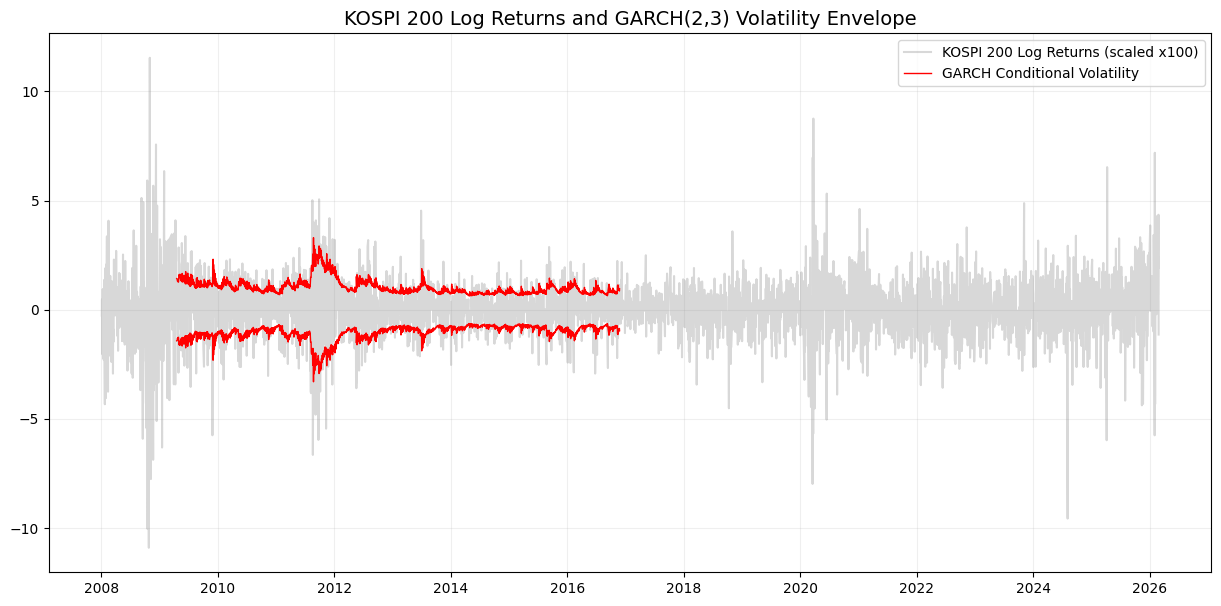

In [19]:
#GARCH 잔차 분석 및 alpha + Beta 값 확인

from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# 1. 최적 모델(best_garch_res)에서 파라미터 및 잔차 추출
# 앞선 셀에서 best_garch_res가 정의되어 있어야 함
params = best_garch_res.params
alpha_sum = sum([params[k] for k in params.keys() if 'alpha' in k])
beta_sum = sum([params[k] for k in params.keys() if 'beta' in k])
persistence = alpha_sum + beta_sum

print(f"--- GARCH 모델 파라미터 및 지속성 분석 ---")
print(f"Alpha Sum: {alpha_sum:.4f}")
print(f"Beta Sum:  {beta_sum:.4f}")
print(f"Total Persistence (Alpha + Beta): {persistence:.4f}")

# 2. 표준화된 잔차(Standardized Residuals) 진단
std_resid = best_garch_res.resid / best_garch_res.conditional_volatility
#귀무가설 H_0: 표준화된 잔차 제곱에 자기상관이 없다 (ARCH 효과 제거 성공)
lb_test_resid = acorr_ljungbox(std_resid**2, lags=[10], return_df=True) #Ljung-Box 검정으로 표준화된 잔차 제곱의 자기상관 확인 

print("\n--- 표준화된 잔차 제곱의 Ljung-Box 검정 (ARCH 효과 제거 확인) ---")
display(lb_test_resid)

if lb_test_resid['lb_pvalue'].iloc[0] > 0.05:
    print(f"\n결과: p-value({lb_test_resid['lb_pvalue'].iloc[0]:.4f})가 0.05보다 크므로 변동성 구조가 잘 잡혔습니다.")
else:
    print("\n결과: 잔차에 여전히 자기상관이 남아있습니다.")

# 3. 원본 로그 수익률 vs GARCH 변동성 플랏
plt.figure(figsize=(15, 7))
plt.plot(full_returns_per, color='gray', alpha=0.3, label='KOSPI 200 Log Returns (scaled x100)')
plt.plot(best_garch_res.conditional_volatility, color='red', linewidth=1, label='GARCH Conditional Volatility')
plt.plot(-best_garch_res.conditional_volatility, color='red', linewidth=1)
plt.title(f'KOSPI 200 Log Returns and GARCH({best_pq[0]},{best_pq[1]}) Volatility Envelope', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

#### GARCH forcast

In [20]:
# =========================================================
# GARCH one-step ahead forecast feature 생성
# - best_p, best_q는 train에서 이미 선택된 상태
# - full_returns는 2008년부터의 warm-up 포함 전체 수익률(×100)
# - 오늘 row에 "내일 예측값"을 저장
# =========================================================

import numpy as np
import pandas as pd
from scipy.stats import t

best_p, best_q = best_pq #미리 설정한 차수 

full_returns_per = data_2008['KOSPI 200_Log_Return'].dropna() * 100

#초기 학습창 설정 250정도
initial_window=250
if len(full_returns_per) <= initial_window + 1:
    raise ValueError("full_returns 길이가 initial_window보다 너무 짧습니다.")

garch_mu_t1_list = []
garch_sigma_t1_list = []
garch_var5_t1_list = []
garch_var1_t1_list = []
feature_dates = []

print('--- GARCH One-Step Ahead Forecast 시작 ---')

for i in range(initial_window, len(full_returns_per)):

    current_date = full_returns_per.index[i]

    try:
        # current_date까지의 실제 데이터만 사용
        past_returns = full_returns_per.iloc[:i+1].dropna()

        model = arch_model(
            past_returns,
            mean='Constant',
            vol='Garch',
            p=best_p,
            q=best_q,
            dist='t'
        )
        res = model.fit(disp='off')

        # 1-step ahead forecast
        fcast = res.forecast(horizon=1, reindex=False)

        mu_t1 = fcast.mean.iloc[-1, 0]
        var_t1 = fcast.variance.iloc[-1, 0]
        sigma_t1 = np.sqrt(var_t1)

        # t-분포 자유도 추출
        nu = res.params.get('nu', np.nan)

        # arch의 standardized t 분포 quantile 보정
        if np.isfinite(nu) and nu > 2:
            q05 = t.ppf(0.05, df=nu) * np.sqrt((nu - 2) / nu)
        else:
            q05 = np.nan

        # return 기준 VaR 예측값
        var5_t1 = mu_t1 + sigma_t1 * q05

        # 오늘 row의 feature로 저장
        garch_mu_t1_list.append(mu_t1)
        garch_sigma_t1_list.append(sigma_t1)
        garch_var5_t1_list.append(var5_t1)
        feature_dates.append(current_date)

    except Exception as e:
        print(f'{current_date} forecast 실패: {e}')
        garch_mu_t1_list.append(np.nan)
        garch_sigma_t1_list.append(np.nan)
        garch_var5_t1_list.append(np.nan)
        feature_dates.append(current_date)

# feature DataFrame 생성
garch_feature_df = pd.DataFrame({
    'GARCH_mu_t1': garch_mu_t1_list,
    'GARCH_sigma_t1': garch_sigma_t1_list,
    'GARCH_VaR_5_t1': garch_var5_t1_list
}, index=feature_dates)

# 원본 데이터에 결합
# 원본 데이터에 결합 (기존 동일 컬럼 제거 후 다시 붙이기)
cols_to_drop = ['GARCH_mu_t1', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1']
data_2008_garch = data_2008.copy()
data_2008_garch = data_2008_garch.drop(columns=cols_to_drop, errors='ignore')
data_2008_garch = data_2008_garch.join(garch_feature_df, how='left')

print('\n--- 생성된 GARCH one-step forecast feature 일부 확인 ---')
display(
    data_2008_garch.loc[feature_dates, [
        'KOSPI 200_Log_Return',
        'GARCH_mu_t1',
        'GARCH_sigma_t1',
        'GARCH_VaR_5_t1'
    ]].head(5)
)

--- GARCH One-Step Ahead Forecast 시작 ---

--- 생성된 GARCH one-step forecast feature 일부 확인 ---


,KOSPI 200_Log_Return,GARCH_mu_t1,GARCH_sigma_t1,GARCH_VaR_5_t1
Date,,,,
2009-01-07,0.028731,-0.114355,2.183001,-3.688734
2009-01-08,-0.022563,-0.120057,2.697223,-4.537479
2009-01-09,-0.023019,-0.122991,2.154206,-3.651292
2009-01-12,-0.020710,-0.128320,2.336690,-3.956122
2009-01-13,0.009491,-0.126168,2.354590,-3.982796


In [21]:
data_2008_garch.tail(10)

,Brent Crude Oil,Gold Spot,USD/KRW,NASDAQ,KOSDAQ,KOSPI 200 Close,KOSPI 200 Open,KOSPI 200 High,KOSPI 200 Low,KOSPI 200 Volume,...,KODEX 200_Close,KODEX 200_NAV,KODEX 200_Premium,KOSPI 200 Return,KOSPI 200 lagged_1_return(%),KOSPI 200 lagged_2_return(%),KOSPI 200_Log_Return,GARCH_mu_t1,GARCH_sigma_t1,GARCH_VaR_5_t1
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-11,69.400002,5071.600098,1455.329956,23066.470703,1114.869995,788.750000,778.250000,792.229980,772.409973,251100000.0,...,79115.0,79252.57,-0.17,1.018160,-0.023051,4.296170,0.010182,0.047973,2.603578,-4.110101
2026-02-12,67.519997,4923.700195,1444.189941,22597.150391,1125.989990,816.280029,800.150024,816.280029,796.359985,316200000.0,...,81975.0,82017.02,-0.05,3.430806,1.018160,-0.023051,0.034308,0.048070,2.637959,-4.165282
2026-02-13,67.750000,5022.000000,1440.900024,22546.669922,1106.079956,814.590027,815.969971,827.140015,811.159973,333800000.0,...,81860.0,81851.45,0.01,-0.207252,3.430806,1.018160,-0.002073,0.048075,2.659969,-4.200167
2026-02-19,71.660004,4975.899902,1440.160034,22682.730469,1160.709961,840.239990,836.119995,841.950012,830.570007,391900000.0,...,84390.0,84431.90,-0.05,-0.207252,3.430806,1.018160,0.031003,0.048155,2.498797,-3.942967
2026-02-20,71.760002,5059.299805,1447.750000,22886.070312,1154.000000,859.590027,842.559998,860.219971,839.979980,352700000.0,...,86300.0,86371.82,-0.08,2.276801,3.430806,1.018160,0.022768,0.048244,2.620355,-4.137225
2026-02-23,71.489998,5204.700195,1443.439941,22627.269531,1151.989990,865.489990,874.929993,879.849976,856.900024,356700000.0,...,86940.0,86968.39,-0.03,0.684025,2.276801,1.018160,0.006840,0.048309,2.482679,-3.917079
2026-02-24,70.769997,5155.799805,1442.199951,22863.679688,1165.000000,886.880005,866.440002,886.950012,855.130005,253500000.0,...,89085.0,89117.82,-0.04,2.441388,0.684025,2.276801,0.024414,0.048395,2.374369,-3.744202
2026-02-25,70.849998,5206.399902,1439.989990,23152.080078,1165.250000,903.830017,895.380005,913.669983,888.960022,348800000.0,...,90890.0,90825.53,0.07,1.893162,2.441388,0.684025,0.018932,0.048487,2.474667,-3.904428
2026-02-26,70.750000,5176.500000,1426.930054,22878.380859,1188.150024,944.020020,910.729980,945.169983,908.119995,361800000.0,...,95025.0,95048.86,-0.03,4.350606,1.893162,2.441388,0.043506,0.048514,2.540873,-4.010446


### GJR-GARCH 모델링

In [22]:

# =========================================================
# GJR-GARCH(p,1,q) 차수 선택(train_returns_garch) + 
# full_returns_per 기반 1-step ahead feature 생성
# =========================================================

train_returns_gjr = train_returns['KOSPI 200_Log_Return']*100

# 1) train 데이터로 GJR-GARCH 차수(p,q) 선택 (o=1 고정)
gjr_best_aic = float('inf')
gjr_best_order = None
gjr_best_res = None

for p in range(1, 4):
    for q in range(1, 4):
        try:
            gjr_model = arch_model(
                train_returns_gjr.dropna(),
                mean='Constant',
                vol='GARCH',
                p=p,
                o=1,   # GJR 비대칭 항
                q=q,
                dist='t'
            )
            gjr_res = gjr_model.fit(disp='off')

            if gjr_res.aic < gjr_best_aic:
                gjr_best_aic = gjr_res.aic
                gjr_best_order = (p, 1, q)
                gjr_best_res = gjr_res

            print(f"GJR-GARCH({p},1,{q}) - AIC: {gjr_res.aic:.2f}")
        except Exception as e:
            print(f"GJR-GARCH({p},1,{q}) 실패: {e}")
            continue

print(f"\n[최적 결과] Best GJR-GARCH Order: {gjr_best_order}, AIC: {gjr_best_aic:.2f}")
print(gjr_best_res.summary())


GJR-GARCH(1,1,1) - AIC: 5125.75
GJR-GARCH(1,1,2) - AIC: 5127.75
GJR-GARCH(1,1,3) - AIC: 5129.25
GJR-GARCH(2,1,1) - AIC: 5127.75
GJR-GARCH(2,1,2) - AIC: 5129.75
GJR-GARCH(2,1,3) - AIC: 5131.25
GJR-GARCH(3,1,1) - AIC: 5129.75
GJR-GARCH(3,1,2) - AIC: 5131.75
GJR-GARCH(3,1,3) - AIC: 5133.25

[최적 결과] Best GJR-GARCH Order: (1, 1, 1), AIC: 5125.75
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:         KOSPI 200_Log_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -2556.88
Distribution:      Standardized Student's t   AIC:                           5125.75
Method:                  Maximum Likelihood   BIC:                           5158.88
                                              No. Observations:                 1848
Date:                      Wed, May 06 2026   Df Residuals:   

In [23]:
# 2) full_returns_per로 expanding window 1-step ahead 예측
gjr_p, gjr_o, gjr_q = gjr_best_order

gjr_mu_t1_list = []
gjr_sigma_t1_list = []
gjr_var5_t1_list = []
gjr_feature_dates = []

initial_window=250

for i in range(initial_window, len(full_returns_per)):
    current_date = full_returns_per.index[i]
    past_returns = full_returns_per.iloc[:i+1].dropna()

    try:
        model = arch_model(
            past_returns,
            mean='Constant',
            vol='GARCH',
            p=gjr_p,
            o=gjr_o,
            q=gjr_q,
            dist='t'
        )
        res = model.fit(disp='off')
        fcast = res.forecast(horizon=1, reindex=False)

        mu_t1 = fcast.mean.iloc[-1, 0]
        var_t1 = fcast.variance.iloc[-1, 0]
        sigma_t1 = np.sqrt(var_t1)

        nu = res.params.get('nu', np.nan)
        if np.isfinite(nu) and nu > 2:
            q05 = t.ppf(0.05, df=nu) * np.sqrt((nu - 2) / nu)
        else:
            q05 = np.nan

        var5_t1 = mu_t1 + sigma_t1 * q05

        gjr_mu_t1_list.append(mu_t1)
        gjr_sigma_t1_list.append(sigma_t1)
        gjr_var5_t1_list.append(var5_t1)
        gjr_feature_dates.append(current_date)

    except Exception:
        gjr_mu_t1_list.append(np.nan)
        gjr_sigma_t1_list.append(np.nan)
        gjr_var5_t1_list.append(np.nan)
        gjr_feature_dates.append(current_date)

# 3) feature DataFrame 생성 및 원본 결합
gjr_feature_df = pd.DataFrame(
    {
        'GJR_mu_t1': gjr_mu_t1_list,
        'GJR_sigma_t1': gjr_sigma_t1_list,
        'GJR_VaR_5_t1': gjr_var5_t1_list
    },
    index=gjr_feature_dates
)

data_2008_gjr = data_2008_garch.copy()

# Join 시 기존 동일 컬럼 제거 후 다시 붙이기
data_2008_gjr = data_2008_gjr.drop(columns=['GJR_mu_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1'], errors='ignore')
data_2008_gjr = data_2008_gjr.join(gjr_feature_df, how='left')

display(data_2008_gjr[['KOSPI 200_Log_Return', 'GJR_mu_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1']].tail())

,KOSPI 200_Log_Return,GJR_mu_t1,GJR_sigma_t1,GJR_VaR_5_t1
Date,,,,
2026-02-23,0.006840,0.034165,2.097620,-3.323919
2026-02-24,0.024414,0.034274,2.052966,-3.252566
2026-02-25,0.018932,0.034380,1.992347,-3.155541
2026-02-26,0.043506,0.034501,2.061917,-3.266903
2026-02-27,-0.011378,0.034422,2.012294,-3.187511


In [24]:
data_2008_gjr.head()

,Brent Crude Oil,Gold Spot,USD/KRW,NASDAQ,KOSDAQ,KOSPI 200 Close,KOSPI 200 Open,KOSPI 200 High,KOSPI 200 Low,KOSPI 200 Volume,...,KOSPI 200 Return,KOSPI 200 lagged_1_return(%),KOSPI 200 lagged_2_return(%),KOSPI 200_Log_Return,GARCH_mu_t1,GARCH_sigma_t1,GARCH_VaR_5_t1,GJR_mu_t1,GJR_sigma_t1,GJR_VaR_5_t1
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-02,97.839996,857.000000,937.119995,2609.629883,707.119995,235.300003,240.470001,240.649994,235.020004,76100000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-03,97.599998,866.400024,935.150024,2602.679932,714.000000,234.669998,232.940002,235.639999,230.860001,69000000.0,...,-0.268104,NaN,NaN,-0.002681,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-04,96.790001,863.099976,939.530029,2504.649902,719.250000,235.770004,234.619995,236.589996,230.410004,91500000.0,...,0.467651,-0.268104,NaN,0.004677,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-07,94.389999,859.599976,939.270020,2499.459961,711.770020,231.000000,229.389999,232.419998,229.089996,86700000.0,...,-2.043906,0.467651,-0.268104,-0.020439,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-08,95.540001,878.000000,938.890015,2440.510010,709.309998,230.339996,231.750000,232.320007,229.190002,88700000.0,...,-0.286125,-2.043906,0.467651,-0.002861,NaN,NaN,NaN,NaN,NaN,NaN


### GARCH VAR 시각화

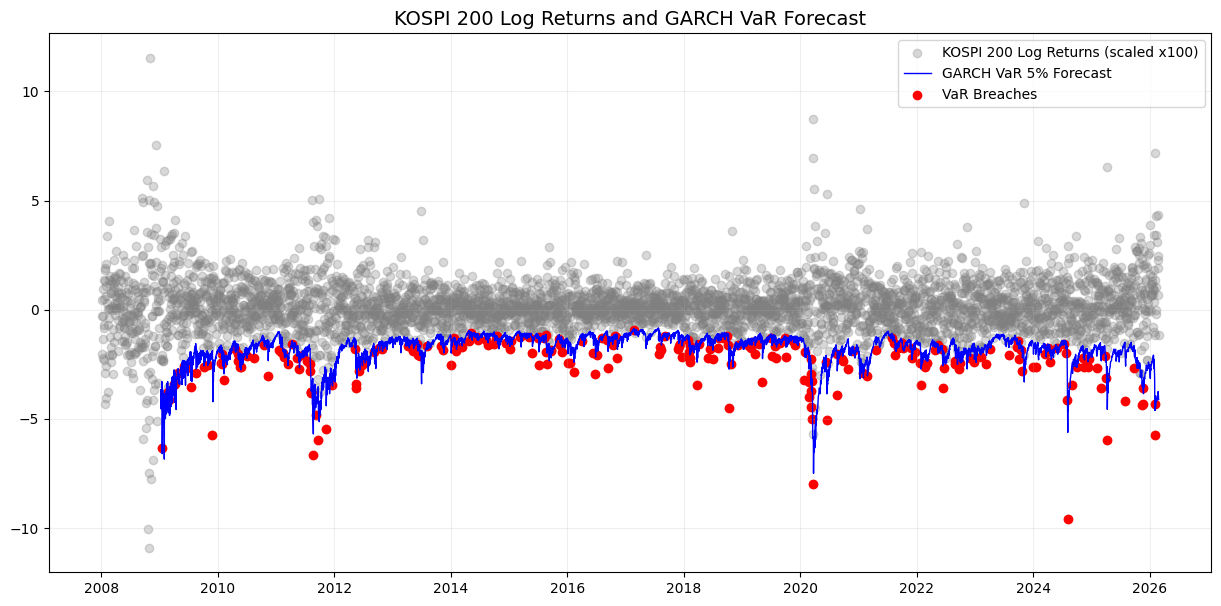

In [25]:
#실제 수익률과 GARCH로 모델링한 VaR scatter 및 파란선으로 시각화
#VaR을 초과한 지점은 빨간색으로 강조 표시
plt.figure(figsize=(15, 7))
plt.scatter(
    data_2008_garch.index,
    data_2008_garch['KOSPI 200_Log_Return'] * 100,
    color='gray',
    alpha=0.3,
    label='KOSPI 200 Log Returns (scaled x100)'
)
plt.plot(
    data_2008_garch.index,
    data_2008_garch['GARCH_VaR_5_t1'],
    color='blue',
    linewidth=1,
    label='GARCH VaR 5% Forecast'
)
# VaR 초과 지점 강조
breaches = data_2008_garch['KOSPI 200_Log_Return'] *100 < data_2008_garch['GARCH_VaR_5_t1']
plt.scatter(
    data_2008_garch.index[breaches],
    data_2008_garch.loc[breaches, 'KOSPI 200_Log_Return'] * 100,
    color='red',
    label='VaR Breaches'
)
plt.title('KOSPI 200 Log Returns and GARCH VaR Forecast', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()



### gjr-GARCH VaR 시각화

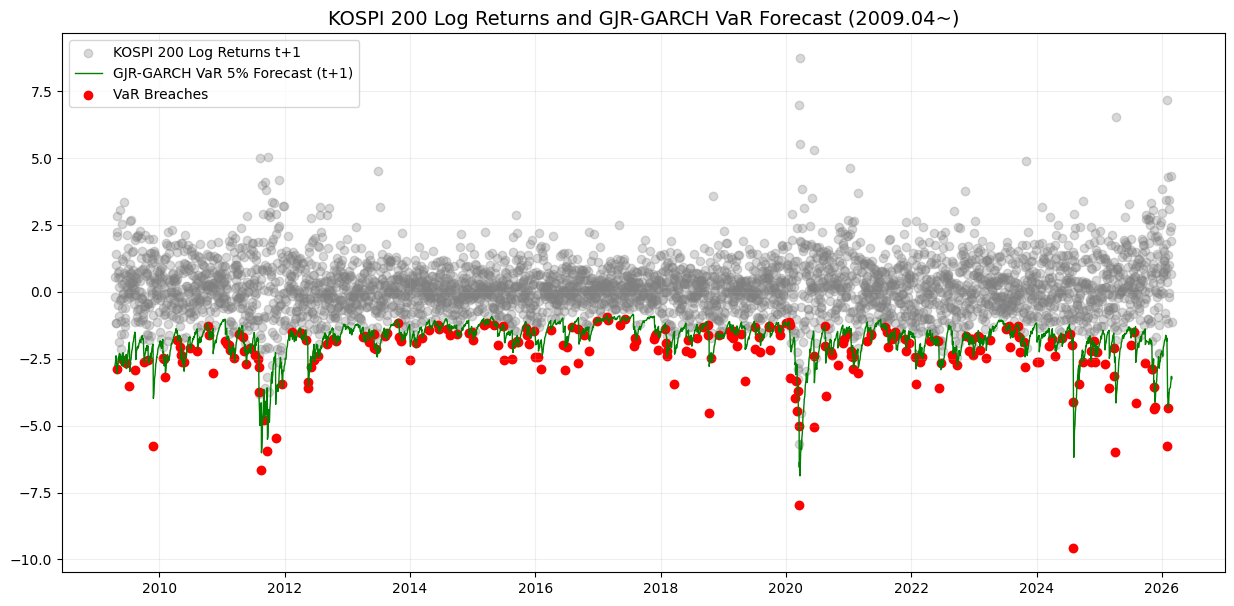

In [26]:
# t+1 로그수익률 컬럼 생성 (shift(-1) = 다음날 수익률)
data_2008_gjr['Log_Return_t1'] = data_2008_gjr['KOSPI 200_Log_Return'] * 100
data_2008_gjr['Log_Return_next'] = data_2008_gjr['Log_Return_t1'].shift(-1)

# 2009.04.17 이후만 필터링
plot_data = data_2008_gjr.loc['2009-04-17':].copy()

# 위반 체크: t+1 수익률 vs t+1 VaR
breaches_gjr = plot_data['Log_Return_next'] < plot_data['GJR_VaR_5_t1']

plt.figure(figsize=(15, 7))
plt.scatter(
    plot_data.index,
    plot_data['Log_Return_next'],
    color='gray',
    alpha=0.3,
    label='KOSPI 200 Log Returns t+1'
)
plt.plot(
    plot_data.index,
    plot_data['GJR_VaR_5_t1'],
    color='green',
    linewidth=1,
    label='GJR-GARCH VaR 5% Forecast (t+1)'
)
plt.scatter(
    plot_data.index[breaches_gjr],
    plot_data.loc[breaches_gjr, 'Log_Return_next'],
    color='red',
    label='VaR Breaches'
)
plt.title('KOSPI 200 Log Returns and GJR-GARCH VaR Forecast (2009.04~)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [27]:
data_2009_gjr = data_2008_gjr.loc['2009-04-17':].copy()

# row t의 당일 수익률 r_t
data_2009_gjr['return(%)'] = data_2009_gjr['KOSPI 200_Log_Return'] * 100

# row t에서 평가해야 하는 다음날 수익률 r_{t+1}
# GJR_VaR_5_t1은 t일 정보로 예측한 t+1 VaR이므로,
# 비교 대상 수익률도 t+1 수익률이어야 함
data_2009_gjr['return_t1(%)'] = data_2009_gjr['return(%)'].shift(-1)

# t+1 수익률 또는 VaR 예측값이 없는 행 제거
data_2009_gjr = data_2009_gjr.dropna(
    subset=['return_t1(%)', 'GJR_VaR_5_t1']
).copy()

data_2009_gjr.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4108 entries, 2009-04-17 to 2026-02-26
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Brent Crude Oil               4108 non-null   float64
 1   Gold Spot                     4108 non-null   float64
 2   USD/KRW                       4108 non-null   float64
 3   NASDAQ                        4108 non-null   float64
 4   KOSDAQ                        4108 non-null   float64
 5   KOSPI 200 Close               4108 non-null   float64
 6   KOSPI 200 Open                4108 non-null   float64
 7   KOSPI 200 High                4108 non-null   float64
 8   KOSPI 200 Low                 4108 non-null   float64
 9   KOSPI 200 Volume              4108 non-null   float64
 10  VKOSPI_Close                  4108 non-null   float64
 11  VKOSPI_Change(%)              4108 non-null   float64
 12  KODEX 200_Close               4108 non-null 

### VaR 분류하기

In [28]:
#train/validation/test를 45:35:20로 나누기
total_len = len(data_2009_gjr)
train_end = int(total_len * 0.45)
val_end = int(total_len * 0.8)
train_data = data_2009_gjr.iloc[:train_end]
val_data = data_2009_gjr.iloc[train_end:val_end]
test_data = data_2009_gjr.iloc[val_end:]

In [29]:
threshold = train_data[train_data['return_t1(%)'] < train_data['GJR_VaR_5_t1']]['return_t1(%)'].max()

threshold

-1.142567856046541

In [30]:
train_data.tail()

,Brent Crude Oil,Gold Spot,USD/KRW,NASDAQ,KOSDAQ,KOSPI 200 Close,KOSPI 200 Open,KOSPI 200 High,KOSPI 200 Low,KOSPI 200 Volume,...,GARCH_mu_t1,GARCH_sigma_t1,GARCH_VaR_5_t1,GJR_mu_t1,GJR_sigma_t1,GJR_VaR_5_t1,Log_Return_t1,Log_Return_next,return(%),return_t1(%)
Date,,,,,,,,,,,,,,,,,,,,,
2016-11-18,46.860001,1208.500000,1179.150024,5321.509766,620.260010,250.210007,250.899994,251.020004,249.229996,78500000.0,...,0.027863,0.965927,-1.519306,0.005253,1.013544,-1.624661,-0.099866,-0.280162,-0.099866,-0.280162
2016-11-21,48.900002,1209.599976,1180.750000,5368.859863,609.330017,249.509995,249.699997,250.800003,248.929993,55400000.0,...,0.027614,0.947148,-1.489363,0.005103,0.989040,-1.585307,-0.280162,1.139727,-0.280162,1.139727
2016-11-22,49.119999,1211.000000,1179.180054,5386.350098,610.739990,252.369995,250.850006,252.850006,250.470001,62500000.0,...,0.028214,0.877588,-1.377573,0.005642,0.961176,-1.540142,1.139727,0.509856,1.139727,0.509856
2016-11-23,48.950001,1189.099976,1167.930054,5380.680176,600.289978,253.660004,253.089996,254.710007,252.220001,68300000.0,...,0.028542,0.975965,-1.534785,0.005961,0.934343,-1.496623,0.509856,-0.644668,0.509856,-0.644668
2016-11-24,48.950001,1189.099976,1180.859985,5380.680176,592.650024,252.029999,253.220001,253.710007,251.440002,53600000.0,...,0.028138,0.899648,-1.413005,0.005537,0.936135,-1.499985,-0.644668,0.091216,-0.644668,0.091216


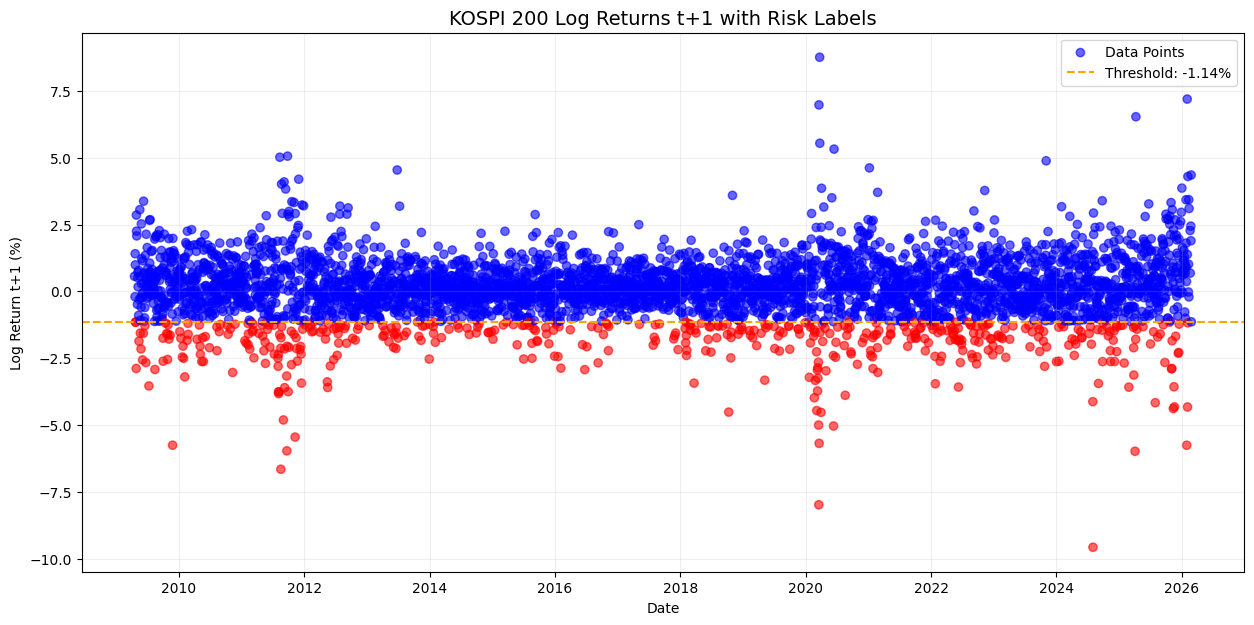

In [31]:
#전체 데이터인 data_2009_gjr에서 threshold를 사용하여 high risk / low risk 구분 
data_2009_gjr['Risk_Label'] = np.where(data_2009_gjr['return_t1(%)'] <= threshold,'High Risk','Low Risk')

#위험 분류한 후 임계값고 데이터를 그래프로 표현
plt.figure(figsize=(15, 7))
plt.scatter(
    data_2009_gjr.index,
    data_2009_gjr['return_t1(%)'],
    color=np.where(data_2009_gjr['Risk_Label'] == 'High Risk', 'red', 'blue'),
    alpha=0.6,
    label='Data Points'
)
plt.axhline(y=threshold, color='orange', linestyle='--', label=f'Threshold: {threshold:.2f}%')
plt.title('KOSPI 200 Log Returns t+1 with Risk Labels', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Log Return t+1 (%)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [32]:
total_len = len(data_2009_gjr)
train_end = int(total_len * 0.45)
val_end = int(total_len * 0.8)
train_data_gjr = data_2009_gjr.iloc[:train_end]
val_data_gjr = data_2009_gjr.iloc[train_end:val_end]
test_data_gjr = data_2009_gjr.iloc[val_end:]

#각 구간의 risk 개수와 비율 출력
print("--- Train Set Risk Distribution ---")    
print(train_data_gjr['Risk_Label'].value_counts())
print("\n--- Validation Set Risk Distribution ---")
print(val_data_gjr['Risk_Label'].value_counts())
print("\n--- Test Set Risk Distribution ---")
print(test_data_gjr['Risk_Label'].value_counts())


--- Train Set Risk Distribution ---
Risk_Label
Low Risk     1638
High Risk     210
Name: count, dtype: int64

--- Validation Set Risk Distribution ---
Risk_Label
Low Risk     1256
High Risk     182
Name: count, dtype: int64

--- Test Set Risk Distribution ---
Risk_Label
Low Risk     723
High Risk     99
Name: count, dtype: int64


### bind하기 편하게 하기위해서 모델링 파생변수들만 뽑기

In [33]:
# 저장용 컬럼: 모델링 파생변수 + 평가용 return_t1 + Risk_Label
feature_cols = data_2009_gjr.columns[data_2009_gjr.columns.get_loc('GARCH_mu_t1'):].tolist()

data_2009_gjr_save = data_2009_gjr[feature_cols].copy()

data_2009_gjr_save.to_csv(r'..\..\data\processed\data_one_step_GARCH_GJR-GARCH_VaR_Label.csv',index=True)

In [34]:
data_2009_gjr=data_2009_gjr[feature_cols]
data_2009_gjr.head()

,GARCH_mu_t1,GARCH_sigma_t1,GARCH_VaR_5_t1,GJR_mu_t1,GJR_sigma_t1,GJR_VaR_5_t1,Log_Return_t1,Log_Return_next,return(%),return_t1(%),Risk_Label
Date,,,,,,,,,,,
2009-04-17,-0.077605,1.847381,-3.088512,-0.114298,1.608928,-2.736404,-0.233192,0.564563,-0.233192,0.564563,Low Risk
2009-04-20,-0.074431,1.907081,-3.181876,-0.110032,1.553372,-2.641002,0.564563,-0.197523,0.564563,-0.197523,Low Risk
2009-04-21,-0.073820,1.796955,-3.000601,-0.109173,1.500503,-2.553085,-0.197523,1.408955,-0.197523,1.408955,Low Risk
2009-04-22,-0.067794,1.656372,-2.766048,-0.101618,1.453282,-2.469281,1.408955,0.992765,1.408955,0.992765,Low Risk
2009-04-23,-0.062765,1.791522,-2.981231,-0.094917,1.406416,-2.386329,0.992765,-1.147696,0.992765,-1.147696,High Risk


TypeError: Axes.text() missing 1 required positional argument: 's'

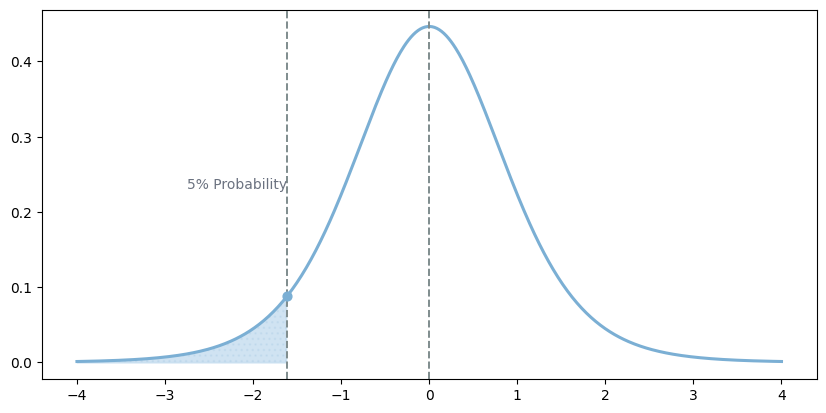

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import t as student_t


def plot_var_explanation_zero_center(tail_prob=0.05, nu=8):
    """Draw a VaR explanation chart centered at 0 using a standardized t distribution."""
    scale = np.sqrt((nu - 2) / nu) if nu > 2 else 1.0
    var_x = student_t.ppf(tail_prob, df=nu) * scale

    x = np.linspace(-4, 4, 600)
    y = student_t.pdf(x / scale, df=nu) / scale

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(x, y, color='#7BAFD4', linewidth=2.2)
    ax.fill_between(x, y, where=x <= var_x, color='#DCEBF7', alpha=1.0)
    ax.fill_between(x, y, where=x <= var_x, color='#7BAFD4', alpha=0.12, hatch='...', edgecolor='#7BAFD4')

    ax.axvline(var_x, color='#7F8C8D', linestyle='--', linewidth=1.4)
    ax.axvline(0, color='#7F8C8D', linestyle='--', linewidth=1.4)

    var_y = student_t.pdf(var_x / scale, df=nu) / scale
    ax.scatter([var_x], [var_y], color='#7BAFD4', s=40, zorder=5)

    ax.text(var_x, y.max() * 0.53, f'{int(tail_prob * 100)}% Probability', ha='right', va='center', color='#6B7280', fontsize=10)
    ax.text(0, -y.max() * 0.08, ha='center', va='top', color='#6B7280')
    ax.text(var_x, -y.max() * 0.08, f'{var_x:.2f}', ha='center', va='top', color='#6B7280')
    ax.text(x.max(), -y.max() * 0.08, 'Standardized Value', ha='right', va='top', color='#6B7280')

    ax.set_title(f't({nu}) 기반 5% VaR', loc='left', fontsize=14, fontweight='bold', color='#3C4A5A')
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#B8C4D0')
    ax.tick_params(axis='x', colors='#6B7280')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:.0f}' if abs(value) >= 1 else f'{value:.1f}'))
    ax.set_xlim(-4, 4)
    ax.set_xlabel('')

    plt.tight_layout()
    return fig, ax


plot_var_explanation_zero_center(tail_prob=0.05, nu=8)
plt.show()